## Final Project Submission

Please fill out:
* Student name:Jenipher Anyango Oduor 
* Student pace: part time
* Scheduled project review date/time: 
* Instructor name: George Kamundia
* Blog post URL:


In [1]:
#Load data

import pandas as pd

df = pd.read_csv("./data/Aviation_Data.csv")
df.head()


C:\Users\jenip\AppData\Local\Temp\ipykernel_16996\2547588308.py:5: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/Aviation_Data.csv")


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [2]:
# To identify the columns in the dataframe

df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [3]:
#Rows, Columns

df.shape

(90348, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90348 entries, 0 to 90347
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      90348 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

First Recommendation
Aircraft Model based on lowest incident rates

For this recommendation, we are going to do analysis on the following columns in the dataset
- Make
- Model
- Investigation.Type
- Aircraft.damage
- Injury.Severity


In [5]:
print(df[["Make", "Model", "Investigation.Type", "Aircraft.damage", "Injury.Severity"]].head())


       Make     Model Investigation.Type Aircraft.damage Injury.Severity
0   Stinson     108-3           Accident       Destroyed        Fatal(2)
1     Piper  PA24-180           Accident       Destroyed        Fatal(4)
2    Cessna      172M           Accident       Destroyed        Fatal(3)
3  Rockwell       112           Accident       Destroyed        Fatal(2)
4    Cessna       501           Accident       Destroyed        Fatal(1)


In [6]:
#Filter the dataframe to keep only actual accidents since we are studing serous risks
df_accidents = df[df['Investigation.Type'] == 'Accident']

# Group by make and model and give number of accidents as Accident_count
aircraft_accidents = df_accidents.groupby(['Make', 'Model']).size().reset_index(name='Accident_Count')

# sort number of acidents from the lowest to the highest
low_risk_aircraft = aircraft_accidents.sort_values('Accident_Count', ascending=True)

#
low_risk_aircraft = low_risk_aircraft[low_risk_aircraft['Accident_Count'] > 2]

print(low_risk_aircraft.head())



                                 Make         Model  Accident_Count
9559                           HUGHES           269               3
7917                       Eurocopter         EC130               3
7433                      EMBRAER S A  ERJ170-200LR               3
7848   Ercoupe (eng & Research Corp.)             G               3
19307                          Zenith         CH601               3


In [7]:
high_risk_aircraft = aircraft_accidents.sort_values('Accident_Count', ascending=False)

print(high_risk_aircraft.head(10))

         Make      Model  Accident_Count
5304   Cessna        152            2155
5326   Cessna        172            1250
5370   Cessna       172N             993
14368   Piper  PA-28-140             809
5279   Cessna        150             711
5368   Cessna       172M             663
5373   Cessna       172P             594
14262   Piper      PA-18             539
5303   Cessna       150M             537
14378   Piper  PA-28-180             498


C:\Users\jenip\AppData\Local\Temp\ipykernel_16996\4044935872.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  safe_aircraft['Make_Model'] = safe_aircraft['Make'] + " " + safe_aircraft['Model']
C:\Users\jenip\AppData\Local\Temp\ipykernel_16996\4044935872.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


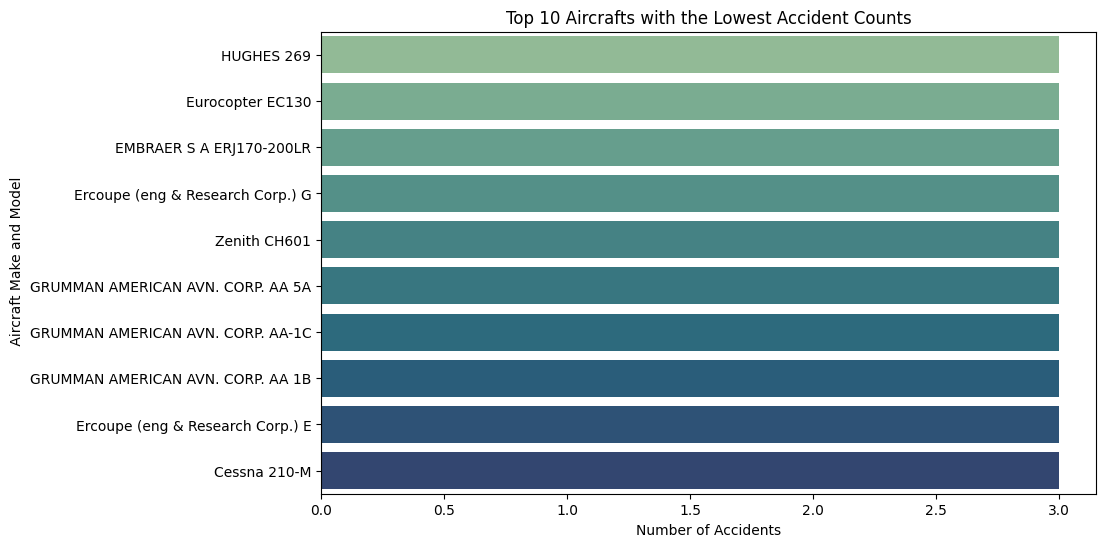

In [8]:
#Visualization of data

import matplotlib.pyplot as plt
import seaborn as sns 


safe_aircraft = low_risk_aircraft.head(10)

safe_aircraft['Make_Model'] = safe_aircraft['Make'] + " " + safe_aircraft['Model']

plt.figure(figsize = (10, 6))
sns.barplot(
    x = "Accident_Count",
    y = "Make_Model",
    data = safe_aircraft,
    palette = "crest"


)
plt.xlabel("Number of Accidents")
plt.ylabel(" Aircraft Make and Model")
plt.title("Top 10 Aircrafts with the Lowest Accident Counts")

plt.show()


Recommendation 2
Aircraft Model based on number of injuries per accident. Aircrafts with the lowest injury counts are considered to be safer.

From the given data set, injury counts are indicated as fatal, serious and minor injuries.
For this recommendation we are going to do analysis using the following columns of the dataset:
- Make
- Model
- Total.Fatal.Injuries
- Total.Serious.Injuries
- Total.Minor.Injuries

In [9]:
# Create a dataframe with the columns we are going to use for analysis

injury_data = df[["Make", "Model", "Total.Fatal.Injuries", "Total.Serious.Injuries", "Total.Minor.Injuries"]]


In [10]:

#Check for missing values in every column
injury_data.isnull().sum()

Make                       1522
Model                      1551
Total.Fatal.Injuries      12860
Total.Serious.Injuries    13969
Total.Minor.Injuries      13392
dtype: int64

In [11]:
# We are going to handle the missing values by replacing with 0

injury_data = injury_data.fillna(0)

In [12]:
#Create a new column for total number of injuries that will be used to compare against the make and model.

injury_data["Total_Injuries"] = injury_data["Total.Fatal.Injuries"] + injury_data["Total.Minor.Injuries"] + injury_data["Total.Serious.Injuries"]

In [13]:
injury_summary = injury_data.groupby(["Make", "Model"]).agg({
    "Total_Injuries": "sum"
}).reset_index()

injury_summary = injury_summary.sort_values("Total_Injuries", ascending=True)


In [14]:
#Top safest aircrafts based on total number of injuries

print(injury_summary.head(10))

                  Make       Model  Total_Injuries
8638   FANTASY AIR SRO  ALLEGRO 20             0.0
6150            Cessna     A 188 A             0.0
6149            Cessna       A 152             0.0
6148            Cessna         750             0.0
6147            Cessna         680             0.0
6146            Cessna    650-0220             0.0
12874            Maule     M-5-210             0.0
6144            Cessna       560XL             0.0
6143            Cessna      560 XL             0.0
6141            Cessna         552             0.0


Recommendation 3
Analyze the dataset to determine which weather conditions are most appropriate for aircraft operations.

For this recommendation we are going to use the Weather.Condition and Injury.Severity columns to compare injury severity across different weather conditions.

In [15]:
#Create a new dataframe with the columns we will use for this

weather_impact = df[["Weather.Condition", "Injury.Severity"]]


In [16]:
# We will handle the missing values in the two columns by replacing with NA

weather_impact["Weather.Condition"] = weather_impact["Weather.Condition"].fillna("NA")
weather_impact["Injury.Severity"] = weather_impact["Injury.Severity"].fillna("NA")


C:\Users\jenip\AppData\Local\Temp\ipykernel_16996\3350650977.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_impact["Weather.Condition"] = weather_impact["Weather.Condition"].fillna("NA")
C:\Users\jenip\AppData\Local\Temp\ipykernel_16996\3350650977.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_impact["Injury.Severity"] = weather_impact["Injury.Severity"].fillna("NA")


In [17]:
#Count the number of accidents for each weather condition

severity_by_weather = weather_impact.groupby(
    ["Weather.Condition", "Injury.Severity"]
).size().reset_index(name="Accident_Count")

severity_by_weather


,Weather.Condition,Injury.Severity,Accident_Count
0,IMC,Fatal,609
1,IMC,Fatal(1),1121
2,IMC,Fatal(10),13
3,IMC,Fatal(107),1
4,IMC,Fatal(11),2
...,...,...,...
182,VMC,Minor,169
183,VMC,NA,55
184,VMC,Non-Fatal,62916
185,VMC,Serious,132
